# diamonds

In [1]:
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df = sns.load_dataset('diamonds')

In [3]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [4]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
df.tail()

,carat,cut,color,clarity,depth,table,price,x,y,z
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


In [6]:
print(df.shape)

(53940, 10)


In [7]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [9]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

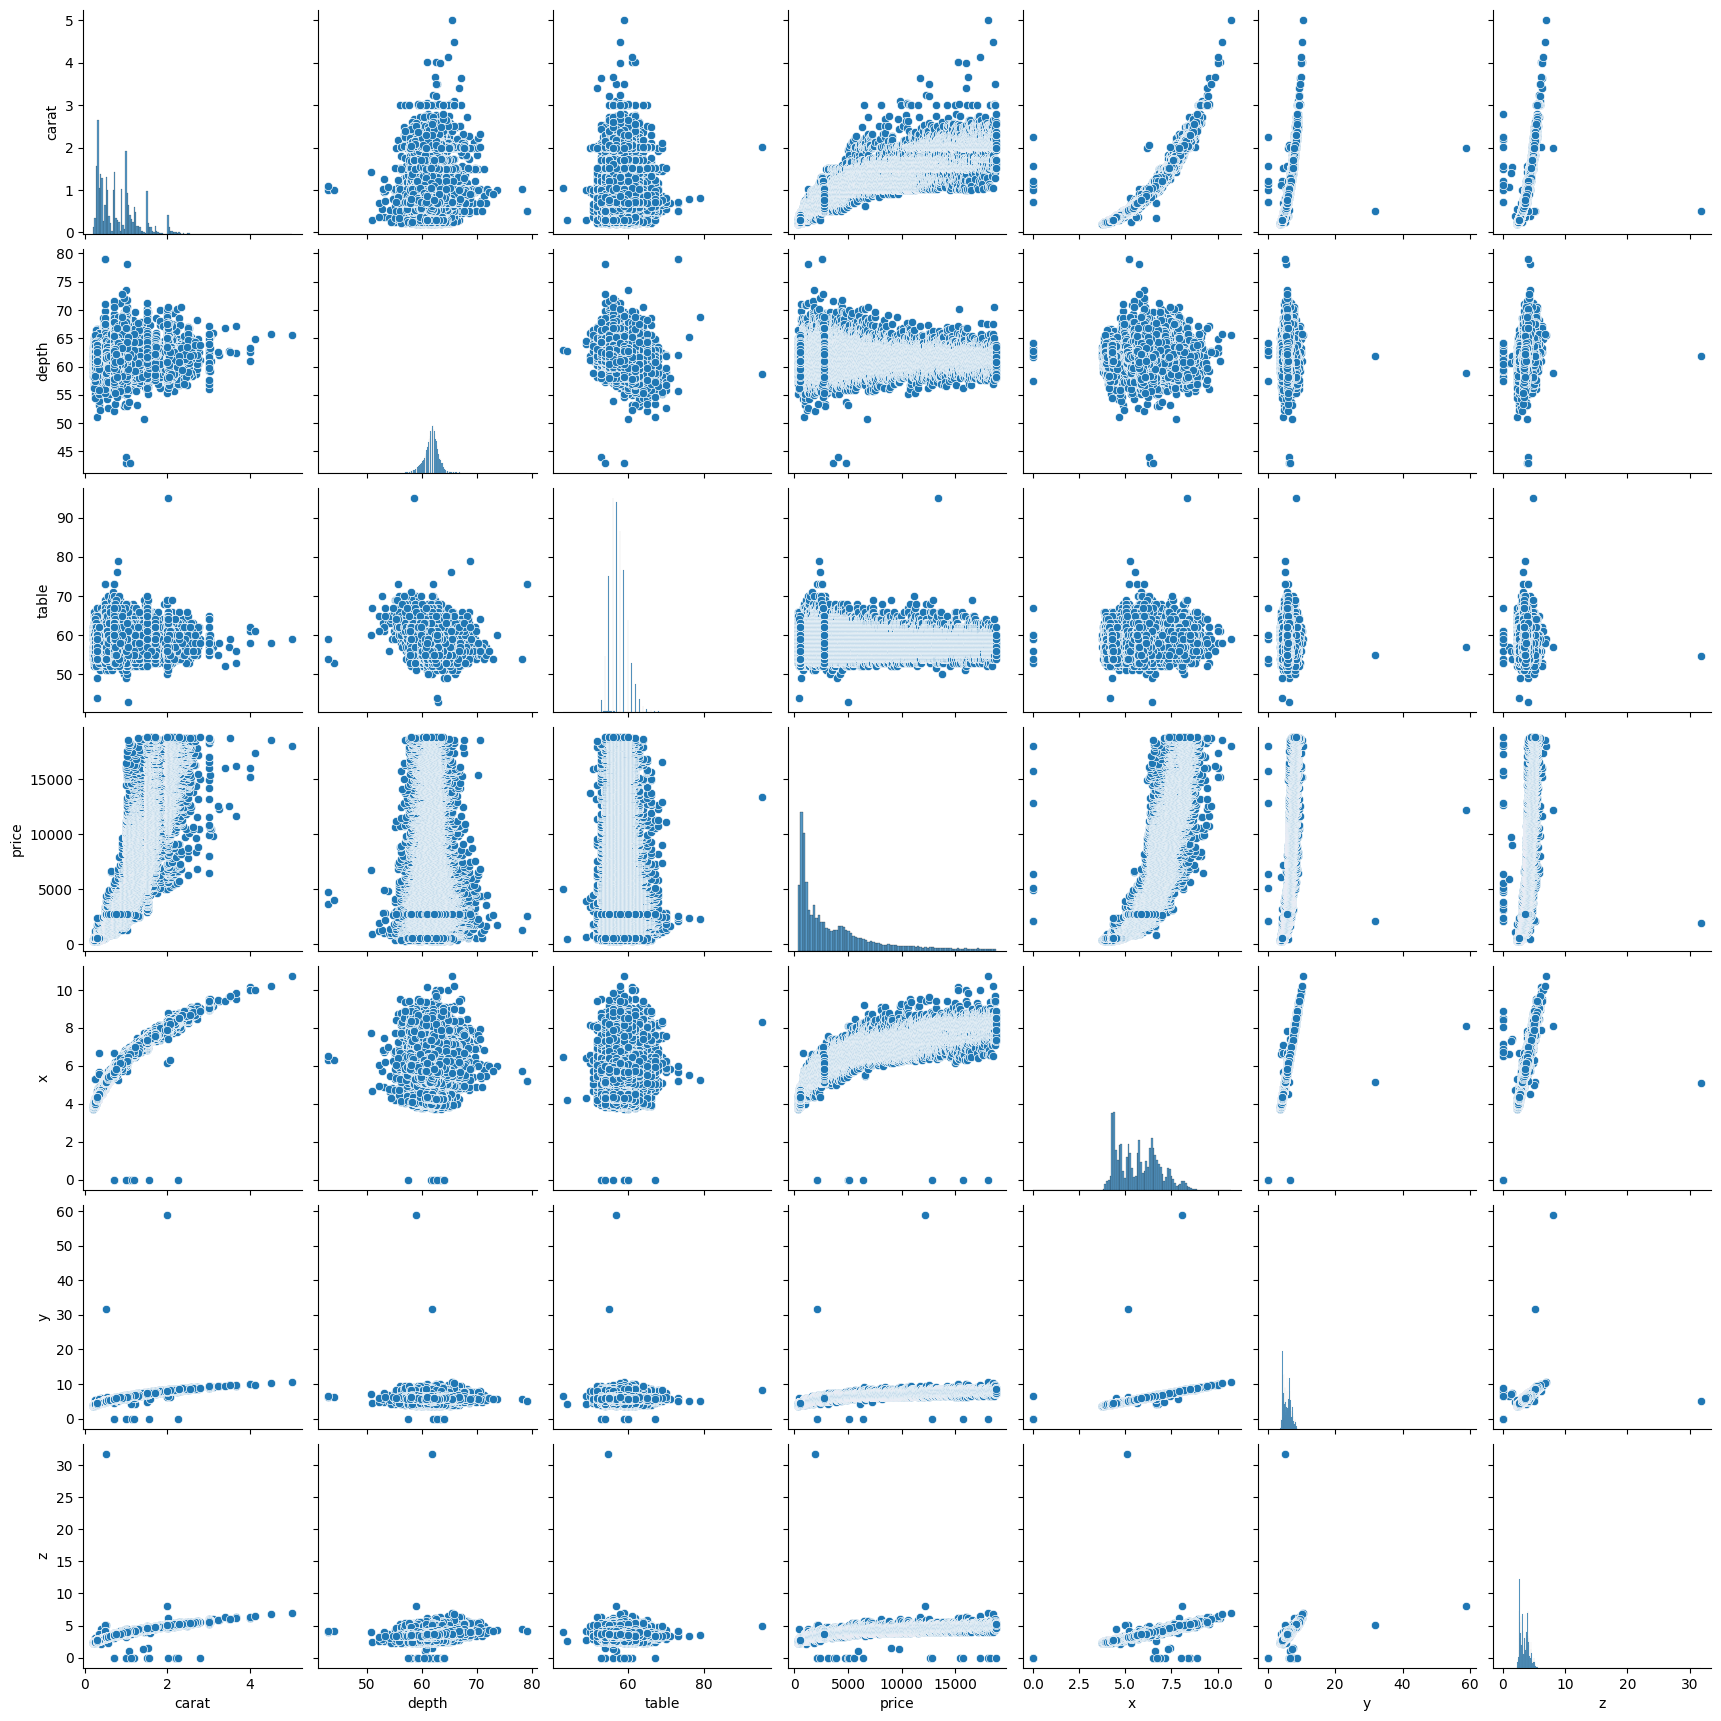

In [12]:
sns.pairplot(df)

<Axes: xlabel='cut', ylabel='carat'>

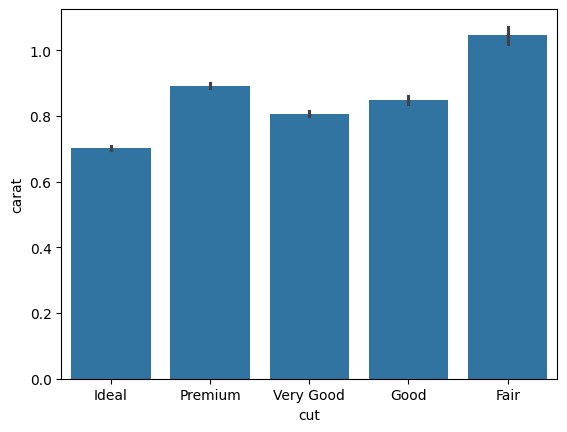

In [13]:
sns.barplot(x='cut', y='carat', data=df)

<Axes: xlabel='cut', ylabel='price'>

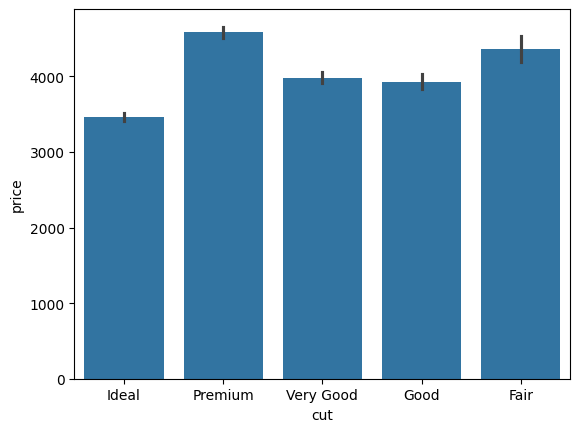

In [14]:
sns.barplot(x='cut', y='price', data=df)

In [15]:
import pandas as pd

def agg_func(col):
    if pd.api.types.is_categorical_dtype(col) or pd.api.types.is_object_dtype(col):
        return 'count'
    elif pd.api.types.is_numeric_dtype(col):
        return 'mean'
    else:
        return 'first'

In [16]:
columns_to_agg = [col for col in df.columns if col != 'cut']

groupedvalues = df.groupby('cut').agg({col: agg_func(df[col]) for col in columns_to_agg}).reset_index()
groupedvalues.head()

/tmp/ipykernel_12738/3343032604.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupedvalues = df.groupby('cut').agg({col: agg_func(df[col]) for col in columns_to_agg}).reset_index()
/tmp/ipykernel_12738/594790445.py:4: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(col) or pd.api.types.is_object_dtype(col):


,cut,carat,color,clarity,depth,table,price,x,y,z
0,Ideal,0.702837,21551,21551,61.709401,55.951668,3457.541970,5.507451,5.520080,3.401448
1,Premium,0.891955,13791,13791,61.264673,58.746095,4584.257704,5.973887,5.944879,3.647124
2,Very Good,0.806381,12082,12082,61.818275,57.956150,3981.759891,5.740696,5.770026,3.559801
3,Good,0.849185,4906,4906,62.365879,58.694639,3928.864452,5.838785,5.850744,3.639507
4,Fair,1.046137,1610,1610,64.041677,59.053789,4358.757764,6.246894,6.182652,3.982770


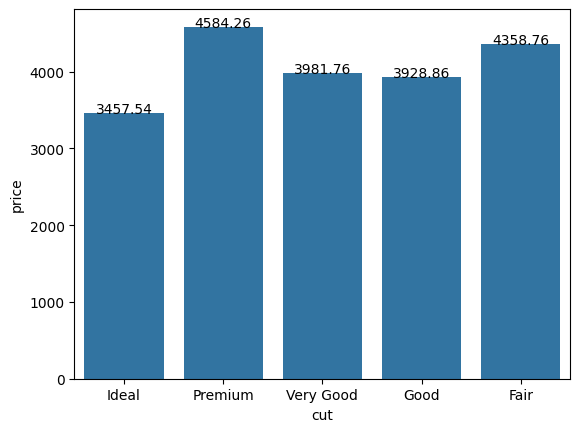

In [17]:
g =sns.barplot(x='cut',y='price',data=groupedvalues)

for index, row in groupedvalues.iterrows():
    g.text(row.name, row.price, round(row.price, 2), color='black', ha="center")

<Axes: xlabel='cut', ylabel='price'>

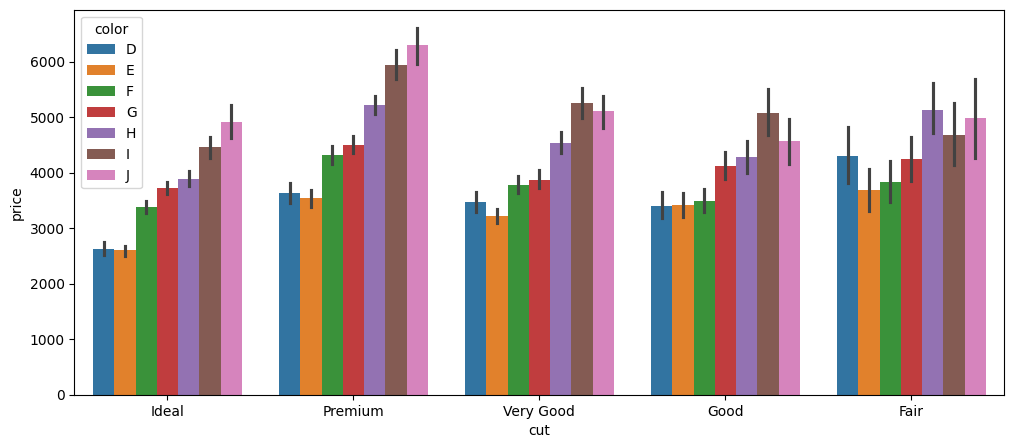

In [18]:
plt.figure(figsize=(12, 5))
sns.barplot(x='cut', y='price', hue = 'color', data=df)

<Axes: xlabel='cut', ylabel='price'>

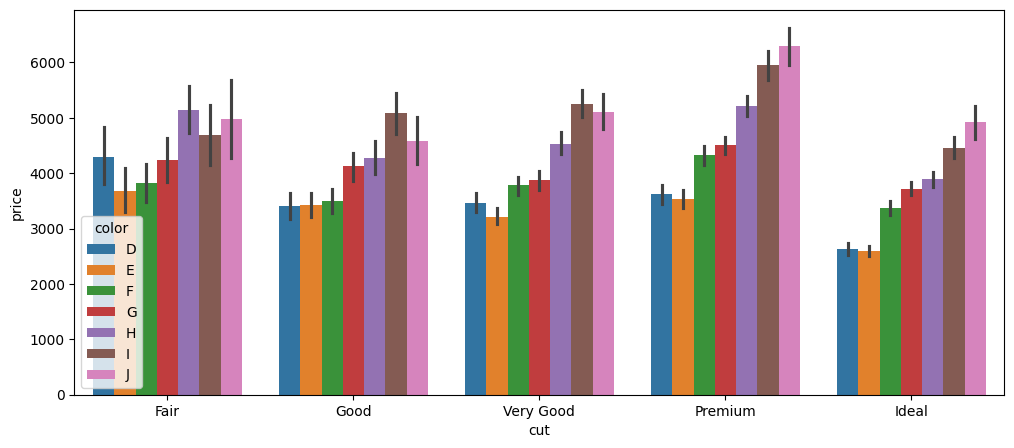

In [19]:
plt.figure(figsize=(12, 5))
sns.barplot(x='cut', y='price', hue = 'color', order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], data=df)

<Axes: xlabel='cut', ylabel='price'>

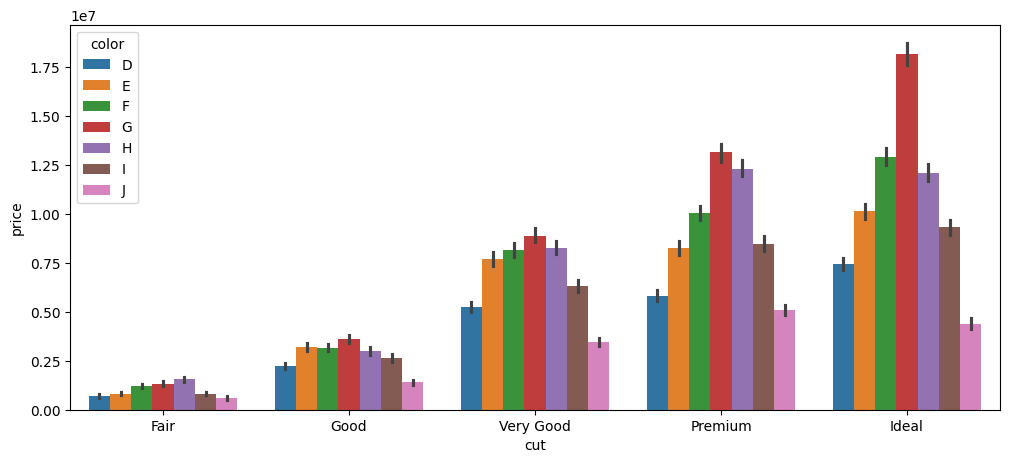

In [20]:
plt.figure(figsize=(12, 5))
sns.barplot(x='cut', y='price', hue = 'color', order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], estimator=sum, data=df)

<Axes: xlabel='cut', ylabel='price'>

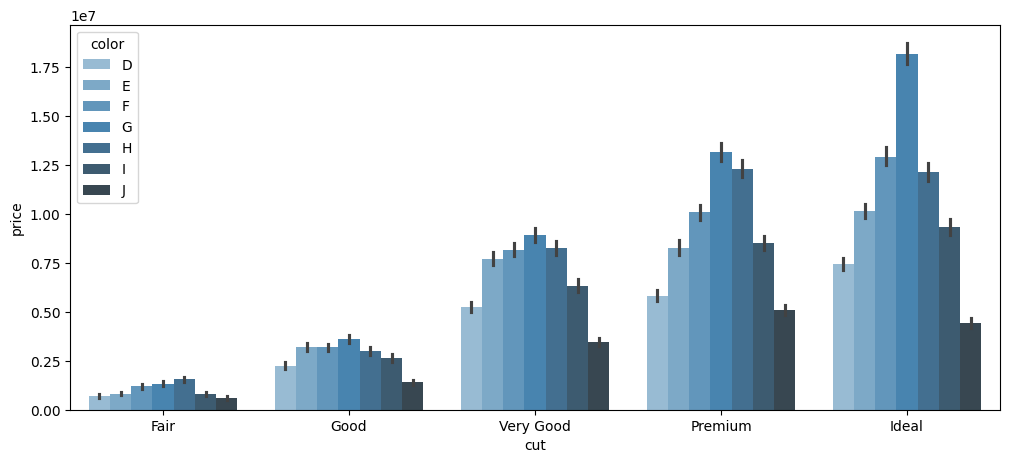

In [21]:
plt.figure(figsize=(12, 5))
sns.barplot(x='cut', y='price', hue = 'color', order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], palette="Blues_d", estimator=sum, data=df)

[Text(0.5, 0, 'cut'), Text(0, 0.5, 'score')]

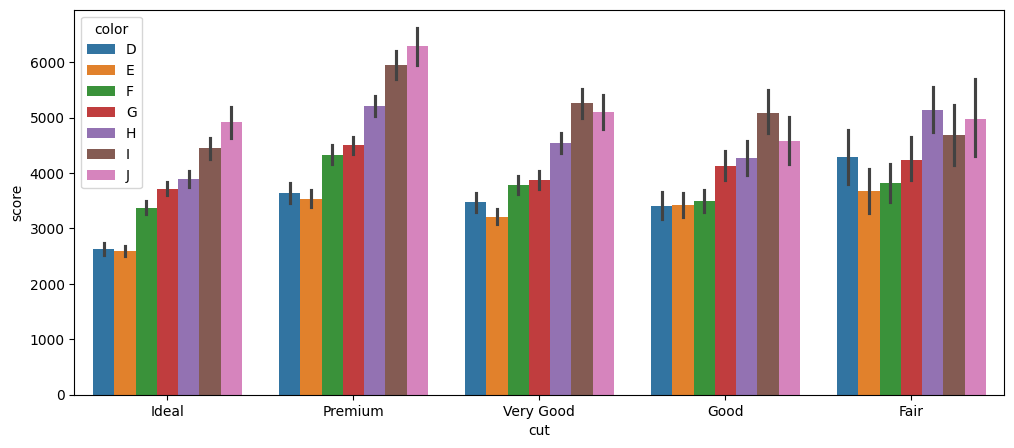

In [22]:
plt.figure(figsize=(12, 5))
sns.barplot(x='cut', y='price', hue = 'color', data=df).set(xlabel='cut', ylabel='score')

Text(0.5, 1.0, 'diamonds')

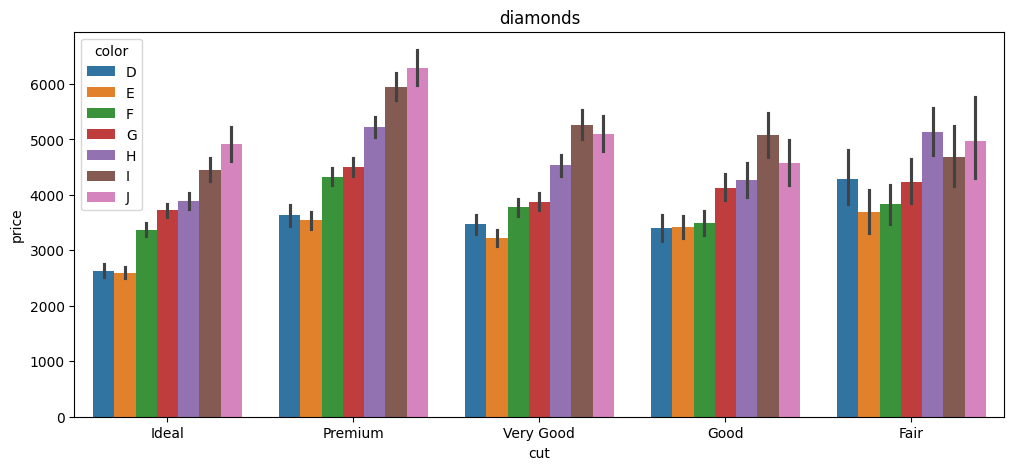

In [23]:
plt.figure(figsize=(12, 5))
sns.barplot(x='cut', y='price', hue = 'color', data=df).set_title('diamonds')

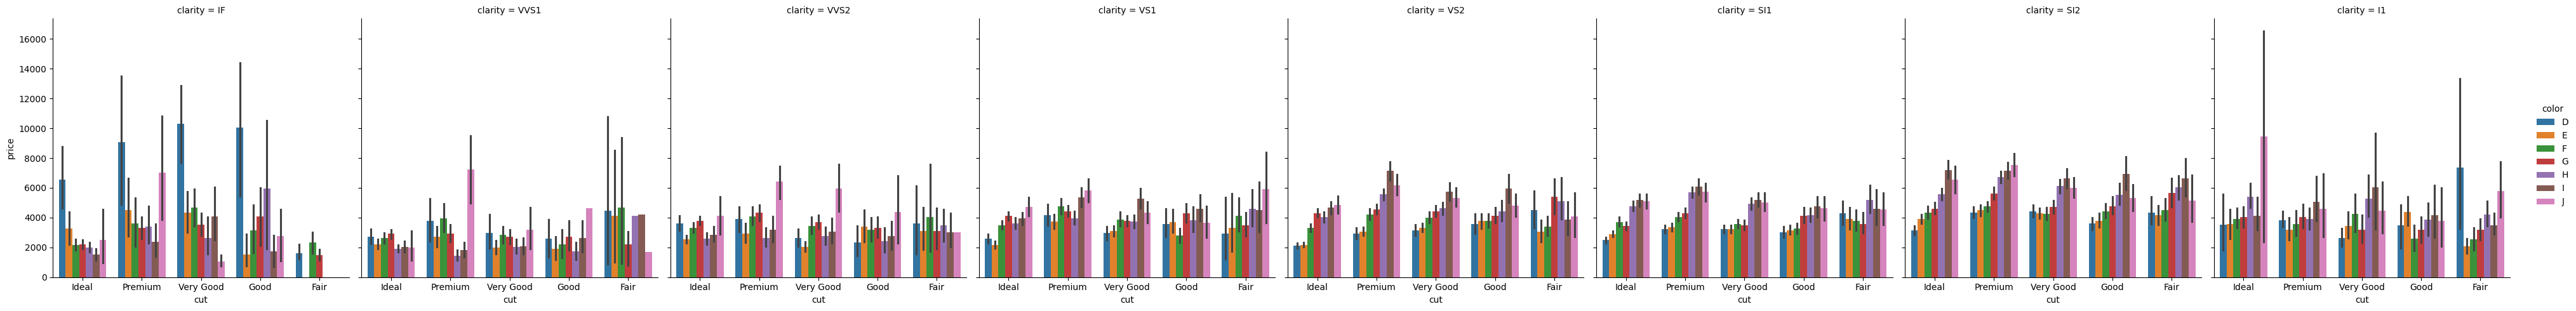

In [24]:
sns.catplot(x='cut', y='price', hue = 'color', col="clarity", data=df, kind="bar")

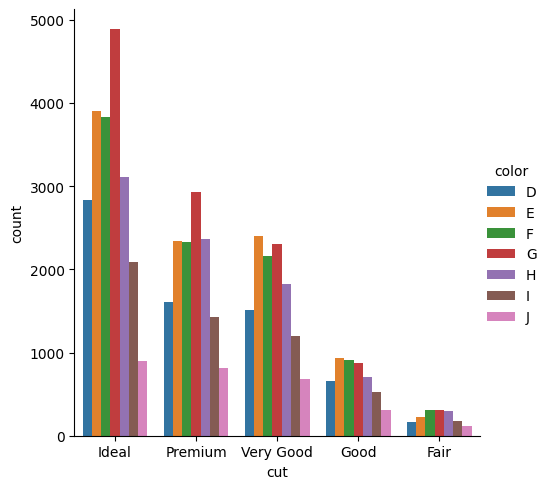

In [25]:
sns.catplot(x ="cut", hue ="color", kind ="count", data = df) 

/tmp/ipykernel_12738/2168984754.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['cut', 'clarity'])


<Axes: xlabel='clarity', ylabel='cut'>

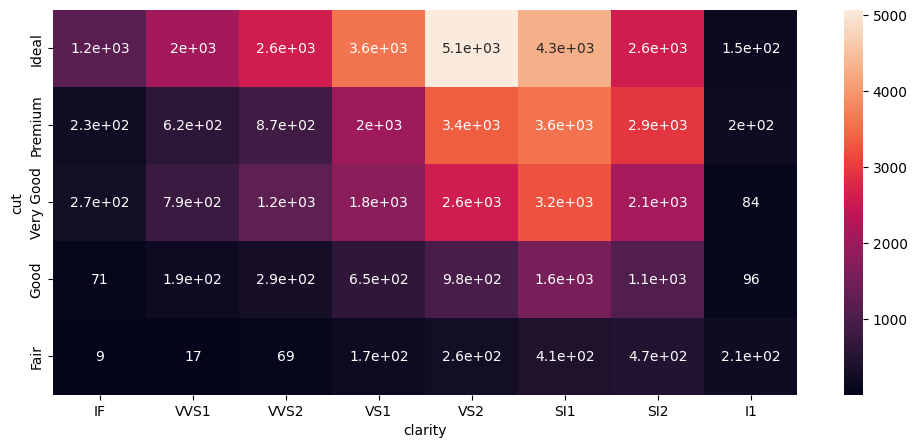

In [26]:
group = df.groupby(['cut', 'clarity']) 
g = group.size().unstack() 
plt.figure(figsize=(12, 5))
sns.heatmap(g, annot = True)

<Axes: xlabel='cut', ylabel='price'>

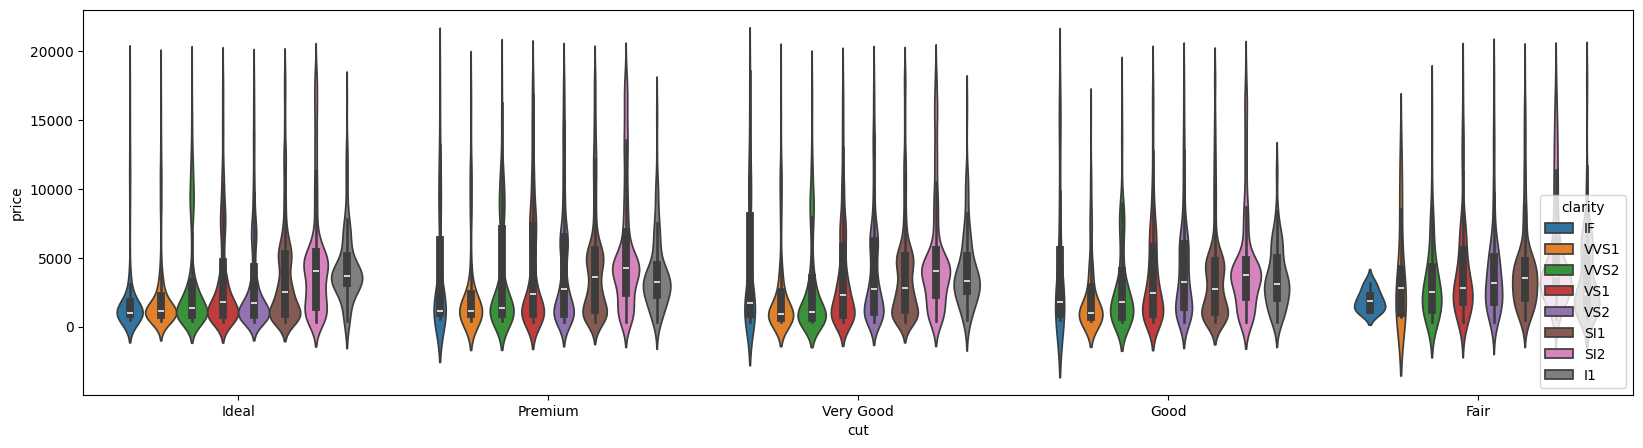

In [27]:
plt.figure(figsize=(20, 5))
sns.violinplot(x ="cut", y ="price", hue ="clarity", data = df)

In [28]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [30]:
print(df.cut.unique())
print(df.color.unique())
print(df.clarity.unique())

['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']


In [31]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

dfi = df.copy()

dfi['cut'] = label_encoder.fit_transform(dfi['cut'])
print(label_encoder.classes_)
dfi['color'] = label_encoder.fit_transform(dfi['color'])
print(label_encoder.classes_)
dfi['clarity'] = label_encoder.fit_transform(dfi['clarity'])
print(label_encoder.classes_)

['Fair' 'Good' 'Ideal' 'Premium' 'Very Good']
['D' 'E' 'F' 'G' 'H' 'I' 'J']
['I1' 'IF' 'SI1' 'SI2' 'VS1' 'VS2' 'VVS1' 'VVS2']


In [32]:
dfi.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


In [33]:
dfi.tail()

,carat,cut,color,clarity,depth,table,price,x,y,z
53935,0.72,2,0,2,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,1,0,2,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,4,0,2,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,3,4,3,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,2,0,3,62.2,55.0,2757,5.83,5.87,3.64


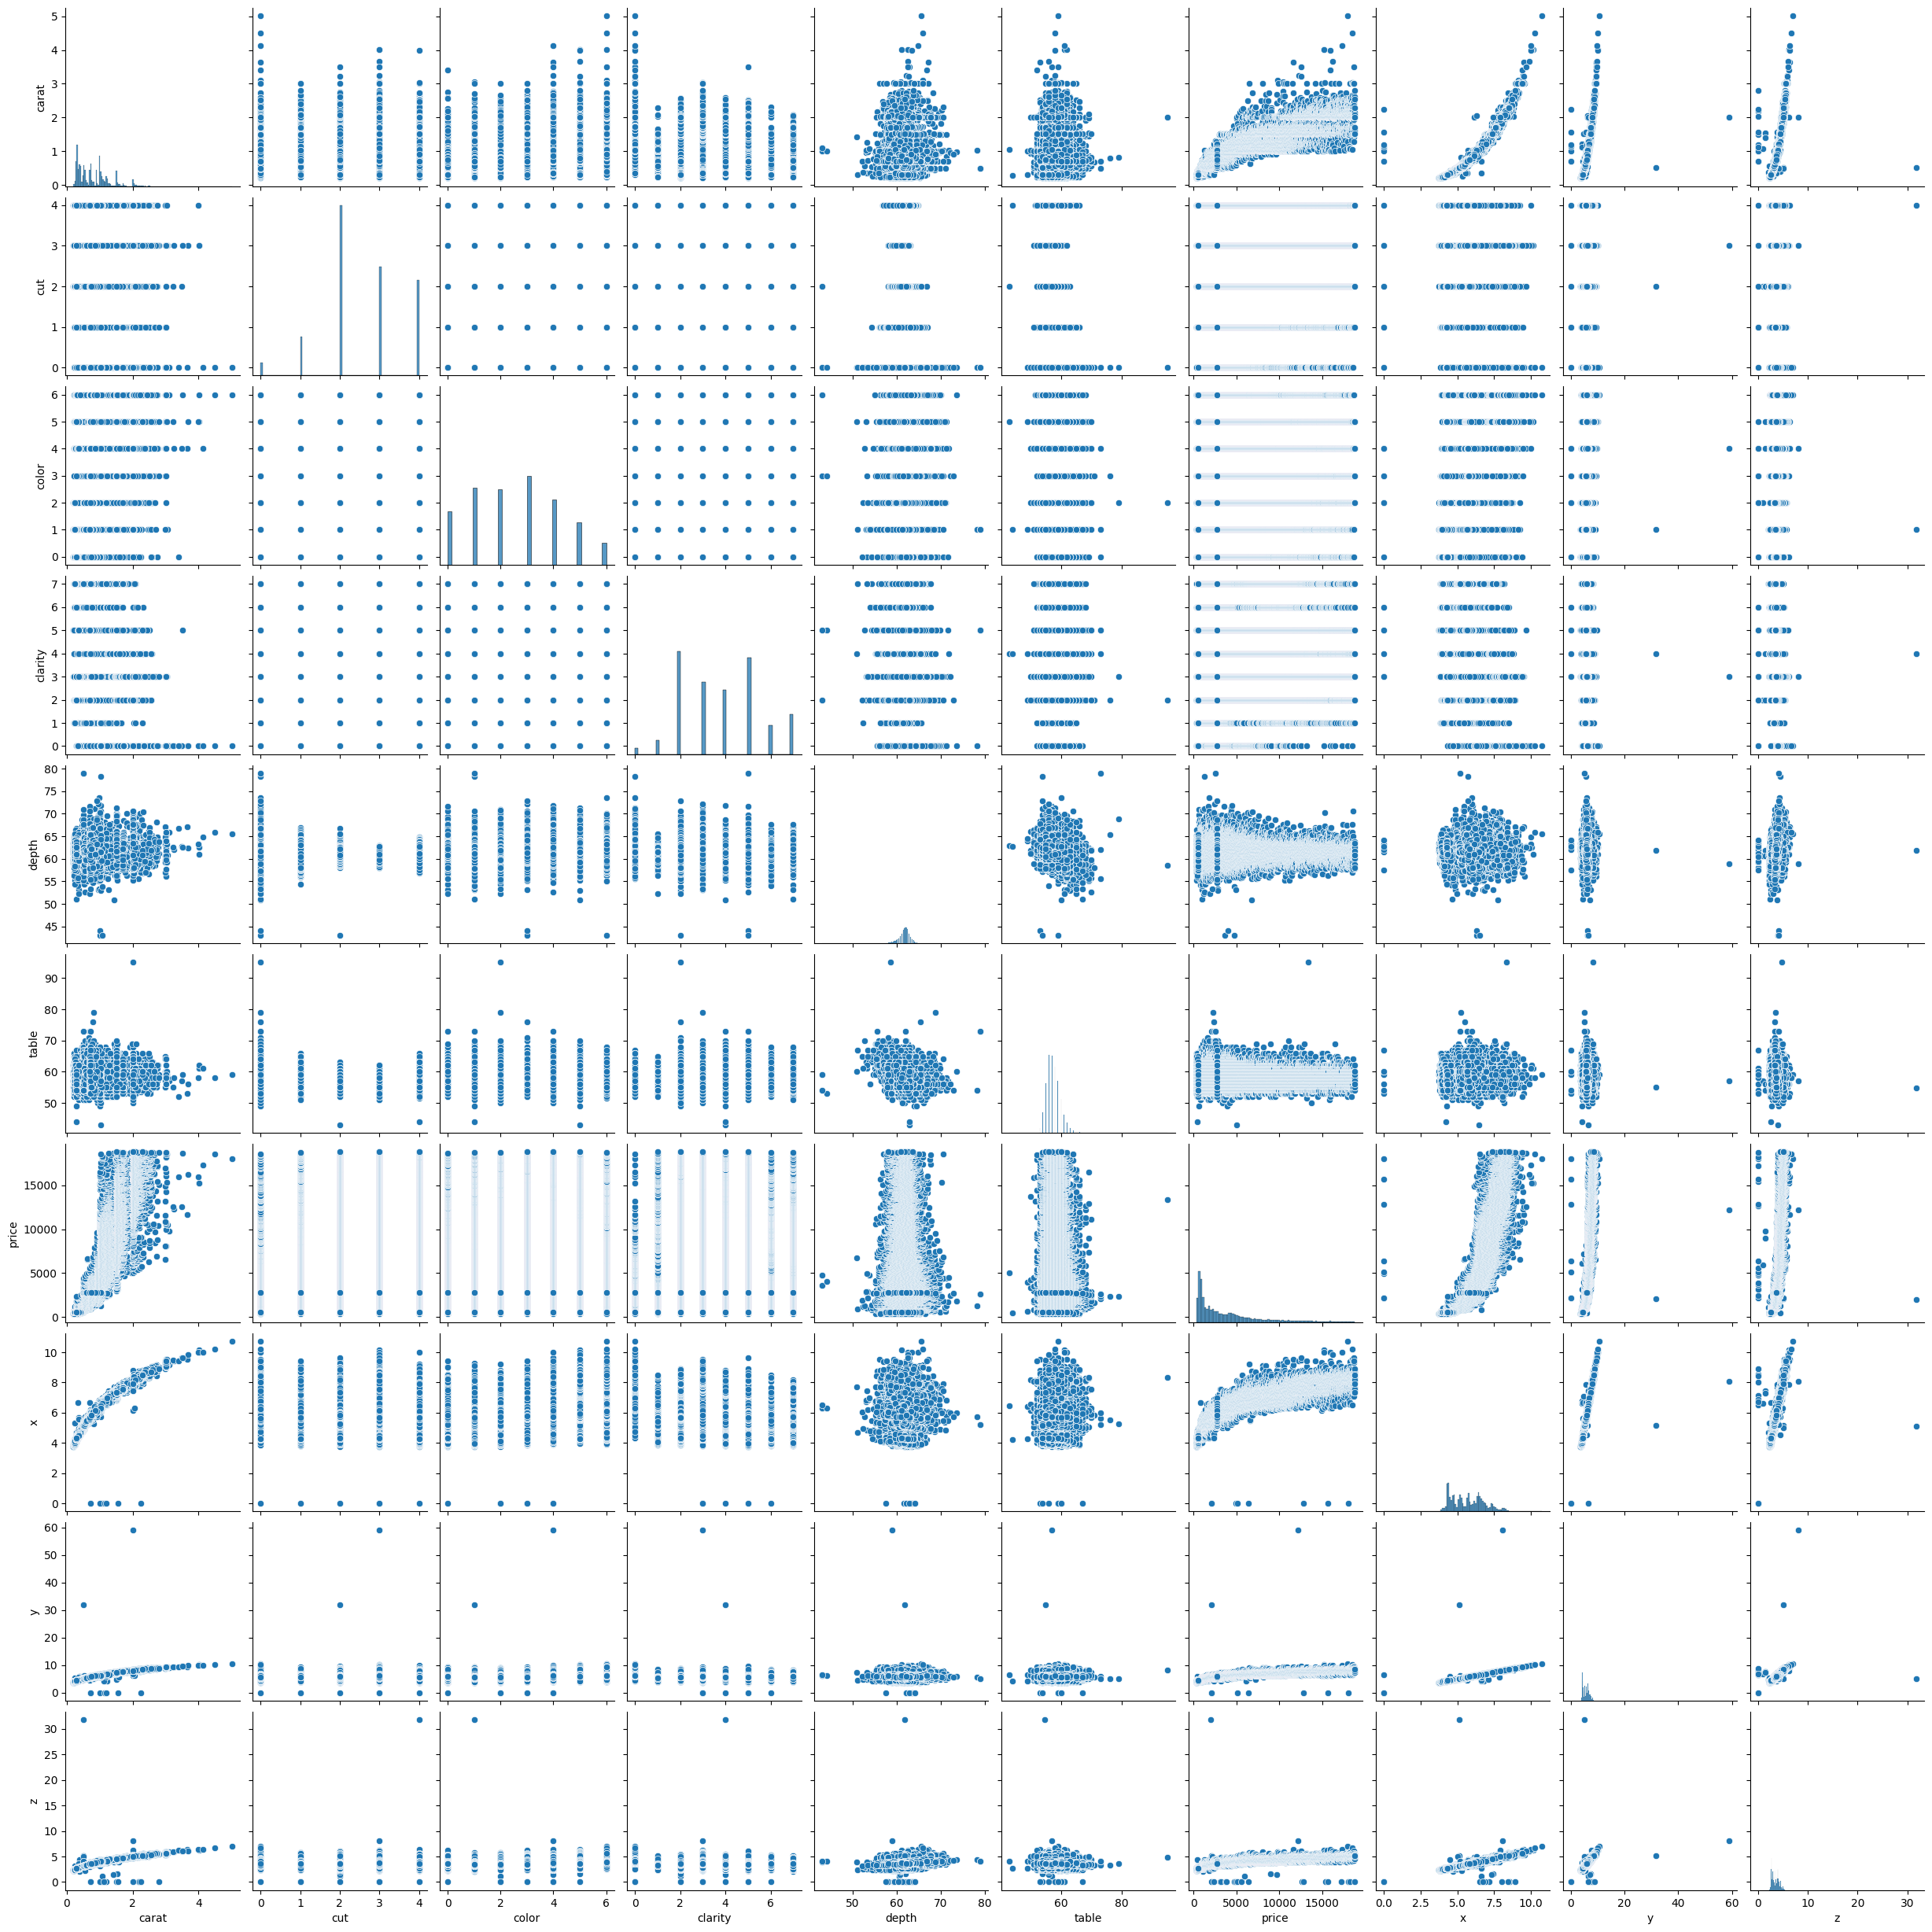

In [34]:
sns.pairplot(dfi)

In [35]:
y_train = dfi[['price']].values
dfi.drop('price', axis=1, inplace=True)
X_train = dfi.values 

In [36]:
print(X_train[:5])

[[ 0.23  2.    1.    3.   61.5  55.    3.95  3.98  2.43]
 [ 0.21  3.    1.    2.   59.8  61.    3.89  3.84  2.31]
 [ 0.23  1.    1.    4.   56.9  65.    4.05  4.07  2.31]
 [ 0.29  3.    5.    5.   62.4  58.    4.2   4.23  2.63]
 [ 0.31  1.    6.    3.   63.3  58.    4.34  4.35  2.75]]


In [37]:
print(y_train[:5])

[[326]
 [326]
 [327]
 [334]
 [335]]


In [38]:
from sklearn import tree

In [39]:
model = tree.DecisionTreeRegressor()

In [40]:
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [41]:
y = model.predict(X_train)

In [42]:
print(y.shape)
print(y_train.shape)

(53940,)
(53940, 1)


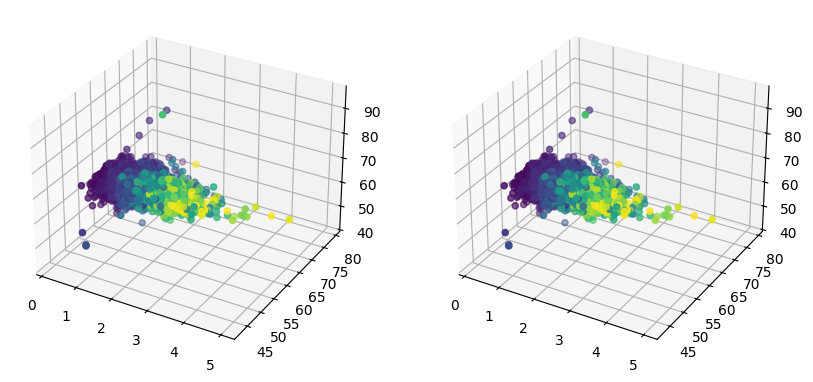

In [43]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d, Axes3D 

fig, axs = plt.subplots(ncols=2, figsize=(10, 5), subplot_kw={"projection":"3d"})
for ax, data in zip(axs, [y, y_train.reshape(-1)]):
    ax.scatter(X_train[:,0], X_train[:,4],X_train[:,5], c=data)
plt.show()

In [44]:
print(model.score(X_train, y_train))

0.9999946493751795
